# 🧑‍🏫 Aula 4 — Aprendizado Não Supervisionado: Detecção de Anomalias em Teares

**UC:** Machine Learning | **Data:** 06/05/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Até aqui (Aulas 1, 2 e 3) trabalhamos com **aprendizado supervisionado** — sempre tínhamos um rótulo (qualidade do tecido) ou um valor alvo (consumo energético). Agora mudamos de paradigma: vamos entrar no **aprendizado não supervisionado**, em que o modelo aprende padrões **sem rótulos**.

Nosso problema industrial: **detectar teares com comportamento anômalo antes que uma falha ocorra** — usando apenas leituras de sensores (temperatura, RPM, torque, desgaste da ferramenta), sem dizer ao modelo quais são as falhas.

1. 🧭 **Entender o que é anomalia** — registros "diferentes demais" do normal operacional
2. 🌳 **Isolation Forest** — isola amostras anômalas com cortes aleatórios em uma floresta
3. 🧑‍🤝‍🧑 **LOF (Local Outlier Factor)** — compara densidade local de vizinhos
4. 🔰 **One-Class SVM** — aprende a fronteira do "normal" e marca o que fica fora
5. 🔵 **DBSCAN** — clusteriza por densidade e trata ruído como anomalia
6. 🗺️ **PCA e t-SNE** — reduzem as features para 2D e permitem **enxergar** as anomalias
7. 📊 **MLflow** — registra cada algoritmo como um run (parâmetros, silhouette, gráficos)

### Recapitulando a trilha:

| Aula | Paradigma | Algoritmos | Alvo |
|---|---|---|---|
| 1 | Supervisionado (classificação) | RandomForest | Qualidade Low/Medium/High |
| 2 | Supervisionado (classificação) | SVM, KNN, XGBoost, LightGBM | Qualidade Low/Medium/High |
| 3 | Supervisionado (regressão) | Ridge, Lasso, ElasticNet, SVR, XGBRegressor | `energy_usage_kwh` |
| **4** | **Não supervisionado (anomalias)** | **Isolation Forest, LOF, One-Class SVM, DBSCAN** | **Sem alvo — apenas "normal" vs "anômalo"** |

---

📦 **Datasets:**
- [Machine Predictive Maintenance Classification](https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification) — 10.000 amostras com leituras de sensores (principal nesta aula)
- [Textile Engineering Production](https://www.kaggle.com/datasets/zara2099/textile-engineering-production-dataset) — 1.000 amostras de produção têxtil (usado na Atividade Complementar)

> 💡 **Importante:** o dataset de manutenção tem uma coluna `Target` (0 = normal, 1 = falha). **Não usaremos essa coluna no treino** — o aprendizado é não supervisionado! Mas no final vamos olhar para ela só para **validar** se o modelo conseguiu, sem ver os rótulos, identificar quem eram os casos de falha.


## 1️⃣ Configuração do Ambiente e Importação de Bibliotecas

Nesta aula reaproveitamos o `scikit-learn` (que já traz todos os detectores de anomalia de que precisamos) e adicionamos uma biblioteca útil para visualização não linear em 2D:

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `pandas` / `numpy` | Manipulação de dados | — |
| `matplotlib` / `seaborn` | Visualizações | — |
| `scikit-learn` | Isolation Forest, LOF, One-Class SVM, DBSCAN, PCA, t-SNE | ✅ Novos algoritmos |
| `mlflow` | Tracking de experimentos | — |
| `joblib` | Salvar/carregar modelos | — |
| `kagglehub` | Download do dataset | — |


In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# Se você já executou as aulas anteriores, a maioria já está instalada.
# A linha abaixo garante que tudo esteja presente nesta sessão.

!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow joblib kagglehub



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# --- Manipulação de Dados ---
import pandas as pd
import numpy as np

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pré-processamento ---
from sklearn.preprocessing import StandardScaler

# *** DETECTORES DE ANOMALIA (scikit-learn) ***
from sklearn.ensemble import IsolationForest          # Isolation Forest
from sklearn.neighbors import LocalOutlierFactor      # LOF
from sklearn.svm import OneClassSVM                   # One-Class SVM
from sklearn.cluster import DBSCAN                    # DBSCAN

# *** REDUÇÃO DE DIMENSIONALIDADE (para VISUALIZAR em 2D) ***
from sklearn.decomposition import PCA                 # Linear
from sklearn.manifold import TSNE                     # Não linear

# *** MÉTRICAS DE APRENDIZADO NÃO SUPERVISIONADO ***
from sklearn.metrics import silhouette_score          # Qualidade de agrupamento

# *** MÉTRICAS SUPERVISIONADAS (só para VALIDAR no final) ***
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

# --- Tracking de Experimentos ---
import mlflow

# --- Utilitários ---
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# Configuração visual
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Todas as bibliotecas foram importadas com sucesso!")


✅ Todas as bibliotecas foram importadas com sucesso!


## 2️⃣ Configuração do MLflow e Pasta de Modelos

Seguindo o padrão das aulas anteriores, criamos **um novo experimento** (`aula04_anomalias_teares`) no mesmo `mlflow.db` compartilhado pelas aulas — assim todo o histórico do curso fica num lugar só — e a pasta `../modelos/aula04/` para salvar os detectores treinados.

```
📁 MLflow Database (mlflow.db)
├── 🧪 aula01_qualidade_textil
├── 🧪 aula02_classificacao_tuning
├── 🧪 aula03_regressao_producao
└── 🧪 aula04_anomalias_teares        ← Nova nesta aula
```


In [3]:
# ============================================================
# CONFIGURAÇÃO DO MLFLOW E DA PASTA DE MODELOS
# ============================================================

# --- Tracking ---
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("aula04_anomalias_teares")

# --- Pasta de modelos (mesmo padrão das aulas anteriores) ---
MODELOS_DIR = os.path.join("..", "modelos", "aula04")
os.makedirs(MODELOS_DIR, exist_ok=True)

# Sufixo padronizado para versionamento e identificação
VERSION_SUFFIX = "anomalias_teares_v1"

print("✅ MLflow configurado!")
print(f"   📁 Tracking URI: {mlflow.get_tracking_uri()}")
print(f"   🧪 Experimento:  aula04_anomalias_teares")
print(f"   💾 Modelos em:   {MODELOS_DIR}/<algoritmo>_<variante>_{VERSION_SUFFIX}.joblib")


2026/05/06 19:46:58 INFO mlflow.tracking.fluent: Experiment with name 'aula04_anomalias_teares' does not exist. Creating a new experiment.


✅ MLflow configurado!
   📁 Tracking URI: sqlite:///../mlflow.db
   🧪 Experimento:  aula04_anomalias_teares
   💾 Modelos em:   ..\modelos\aula04/<algoritmo>_<variante>_anomalias_teares_v1.joblib


## 3️⃣ Carregamento do Dataset de Manutenção Preditiva

O dataset de manutenção traz leituras de **sensores de 10.000 máquinas** (no nosso contexto, 10.000 teares):

| Coluna | Descrição |
|---|---|
| `UDI` | Identificador único (apenas um contador) |
| `Product ID` | ID do produto |
| `Type` | Tipo/qualidade da máquina: L (low), M (medium), H (high) |
| `Air temperature [K]` | Temperatura ambiente em Kelvin |
| `Process temperature [K]` | Temperatura de processo em Kelvin |
| `Rotational speed [rpm]` | Rotação do tear (RPM) |
| `Torque [Nm]` | Torque em Newton·metro |
| `Tool wear [min]` | Desgaste acumulado da ferramenta (min) |
| `Target` | 0 = funcionou / 1 = falhou (**não será usado no treino**) |
| `Failure Type` | Tipo da falha — usado apenas para análise final |

> ⚠️ **Regra do aprendizado não supervisionado:** `Target` e `Failure Type` **não entram no modelo**. São nosso "gabarito oculto" para depois avaliar se o detector encontrou corretamente os teares problemáticos.


In [4]:
# ============================================================
# DOWNLOAD E LEITURA DO DATASET
# ============================================================
# kagglehub baixa apenas na primeira execução; depois usa o cache.

import kagglehub

raw_path = kagglehub.dataset_download(
    "shivamb/machine-predictive-maintenance-classification"
)
csv_files = [f for f in os.listdir(raw_path) if f.endswith(".csv")]
dataset_path = os.path.join(raw_path, csv_files[0])

df = pd.read_csv(dataset_path)

print(f"✅ Dataset carregado de: {dataset_path}")
print(f"📊 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n")
df.head()


100%|██████████| 137k/137k [00:00<00:00, 340kB/s]

Extracting files...
✅ Dataset carregado de: C:\Users\50812123859\.cache\kagglehub\datasets\shivamb\machine-predictive-maintenance-classification\versions\1\predictive_maintenance.csv
📊 Shape: 10,000 linhas × 10 colunas



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
# ============================================================
# CHECAGEM RÁPIDA DE QUALIDADE DOS DADOS
# ============================================================

print("🔎 Tipos de dados:")
print(df.dtypes)

print(f"\n🧪 Valores nulos (total): {df.isnull().sum().sum()}")
print(f"🧪 Linhas duplicadas:     {df.duplicated().sum()}")

print("\n📐 Distribuição do gabarito oculto (Target):")
print(df["Target"].value_counts().to_frame("qtd").assign(
    pct=lambda d: (d["qtd"] / len(df) * 100).round(2).astype(str) + " %"
))

print("\n📐 Tipos de falha:")
print(df["Failure Type"].value_counts())


🔎 Tipos de dados:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

🧪 Valores nulos (total): 0
🧪 Linhas duplicadas:     0

📐 Distribuição do gabarito oculto (Target):
         qtd      pct
Target               
0       9661  96.61 %
1        339   3.39 %

📐 Tipos de falha:
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


## 4️⃣ Pré-processamento — Separar Features e Padronizar

Passos desta seção:

1. **Guardar o gabarito oculto** (`Target`, `Failure Type`) em variáveis separadas — **não entram no modelo**.
2. **Descartar identificadores** (`UDI`, `Product ID`) — não ajudam o modelo.
3. **Transformar `Type`** (L/M/H) em uma variável numérica ordinal.
4. **Padronizar (StandardScaler)** — essencial em detectores baseados em distância/densidade (LOF, One-Class SVM, DBSCAN).

> 💡 **Por que padronizar é tão importante aqui?** "Rotational speed" varia em milhares, "Tool wear" em dezenas e "Temperature" em centenas de Kelvin. Sem padronizar, a feature de maior magnitude domina a distância — e o detector só enxerga essa feature.


In [6]:
# ============================================================
# 4.1 — SEPARAR FEATURES DO GABARITO OCULTO
# ============================================================

# Guardamos o gabarito para análise posterior — NUNCA usamos no treino.
y_true_binary   = df["Target"].values                   # 0 = normal, 1 = falha
y_true_failure  = df["Failure Type"].values             # tipo da falha

# Colunas que NÃO entram no modelo:
#  - UDI e Product ID: identificadores
#  - Target e Failure Type: rótulos (seriam "cola")
cols_drop = ["UDI", "Product ID", "Target", "Failure Type"]
X = df.drop(columns=cols_drop).copy()

# Converte a coluna Type (L/M/H) em número ordinal (0/1/2)
X["Type"] = X["Type"].map({"L": 0, "M": 1, "H": 2})

# Lista das features usada em todos os modelos
feature_names = X.columns.tolist()
print(f"✅ Features usadas no treino ({len(feature_names)}):")
for f in feature_names:
    print(f"   • {f}")
print(f"\n   📐 X shape: {X.shape}")


✅ Features usadas no treino (6):
   • Type
   • Air temperature [K]
   • Process temperature [K]
   • Rotational speed [rpm]
   • Torque [Nm]
   • Tool wear [min]

   📐 X shape: (10000, 6)


In [7]:
# ============================================================
# 4.2 — PADRONIZAÇÃO COM StandardScaler
# ============================================================
# Depois de padronizar, cada feature tem média 0 e desvio 1.
# Isso coloca todas as features na "mesma régua" — fundamental
# para detectores baseados em distância/densidade.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Transformamos de volta em DataFrame para facilitar leitura/visualização.
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names, index=X.index)

print("✅ Features padronizadas (média ≈ 0, desvio ≈ 1):")
print(X_scaled_df.describe().round(2).T[["mean", "std", "min", "max"]])


✅ Features padronizadas (média ≈ 0, desvio ≈ 1):
                         mean  std   min   max
Type                     -0.0  1.0 -0.75  2.23
Air temperature [K]      -0.0  1.0 -2.35  2.25
Process temperature [K]   0.0  1.0 -2.90  2.56
Rotational speed [rpm]   -0.0  1.0 -2.07  7.51
Torque [Nm]               0.0  1.0 -3.63  3.67
Tool wear [min]           0.0  1.0 -1.70  2.28


## 5️⃣ EDA — Como os Dados "se Parecem" em 2D?

Temos 6 features numéricas — não dá para enxergar em um gráfico. Duas técnicas ajudam a **comprimir** esses dados em 2 dimensões só para visualização:

| Técnica | Tipo | Ideia central | Custo |
|---|---|---|---|
| **PCA** | Linear | Projeta os dados nas direções de maior variância | Rápido |
| **t-SNE** | Não linear | Preserva vizinhanças locais (pontos próximos ficam próximos) | Lento |

> 💡 Ambos servem **apenas para visualizar**. Os modelos de anomalia continuam sendo treinados nas **6 features originais padronizadas**, não nos 2 eixos do PCA/t-SNE.

Vamos colorir os pontos com o `Target` só para **nossa** intuição — o modelo não terá acesso a essa informação.


🔍 Variância explicada por PC1: 31.8%
🔍 Variância explicada por PC2: 30.7%
🔍 Total nos 2 primeiros PCs:    62.5%


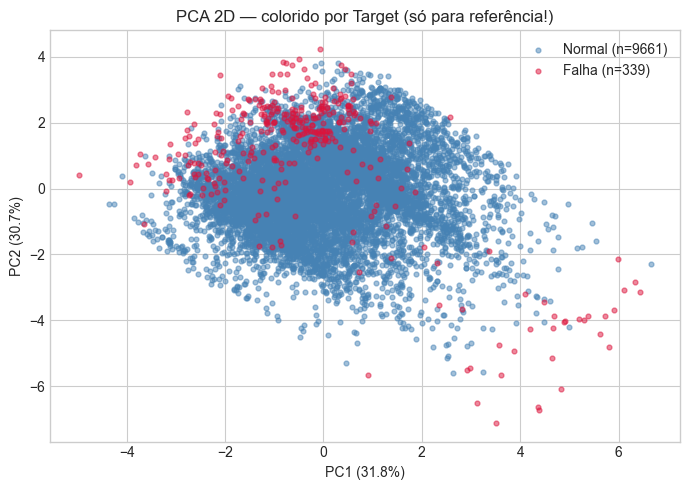

In [8]:
# ============================================================
# 5.1 — PCA (Principal Component Analysis) em 2D
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Quanta "informação" (variância) os 2 componentes capturam?
var_explicada = pca.explained_variance_ratio_
print(f"🔍 Variância explicada por PC1: {var_explicada[0]*100:.1f}%")
print(f"🔍 Variância explicada por PC2: {var_explicada[1]*100:.1f}%")
print(f"🔍 Total nos 2 primeiros PCs:    {var_explicada.sum()*100:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
for classe, cor, label in [(0, "steelblue", "Normal"), (1, "crimson", "Falha")]:
    mask = y_true_binary == classe
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.5,
               c=cor, label=f"{label} (n={mask.sum()})")
ax.set_xlabel(f"PC1 ({var_explicada[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_explicada[1]*100:.1f}%)")
ax.set_title("PCA 2D — colorido por Target (só para referência!)")
ax.legend()
plt.tight_layout()
plt.show()


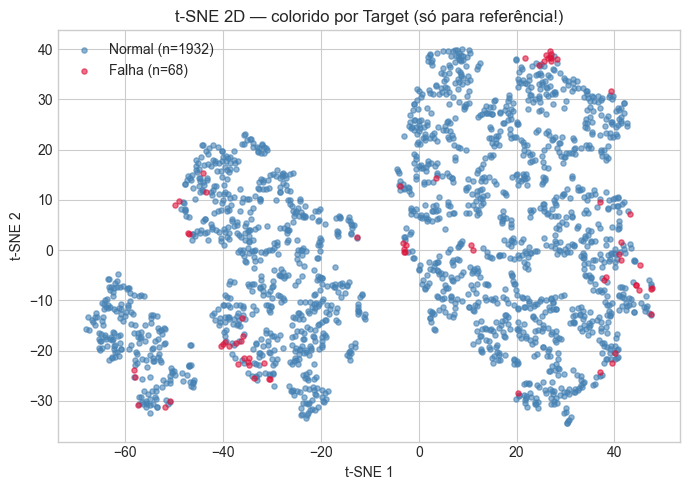

👀 Observação: o t-SNE tende a 'grudar' casos parecidos — as falhas (vermelho) aparecem em pequenos grupos afastados.


In [9]:
# ============================================================
# 5.2 — t-SNE em 2D (amostragem para rodar mais rápido)
# ============================================================
# t-SNE é não linear e escala ~O(n²). Com 10.000 pontos fica lento
# no notebook. Para a visualização, amostramos aleatoriamente 2.000
# pontos mantendo a proporção entre classes (amostragem estratificada).

from sklearn.model_selection import train_test_split

_, idx_sample = train_test_split(
    np.arange(len(X_scaled)),
    test_size=2000,
    stratify=y_true_binary,
    random_state=RANDOM_STATE,
)

X_sample = X_scaled[idx_sample]
y_sample = y_true_binary[idx_sample]

tsne = TSNE(
    n_components=2,
    perplexity=30,       # ~número de vizinhos considerados
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(7, 5))
for classe, cor, label in [(0, "steelblue", "Normal"), (1, "crimson", "Falha")]:
    mask = y_sample == classe
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=14, alpha=0.6,
               c=cor, label=f"{label} (n={mask.sum()})")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE 2D — colorido por Target (só para referência!)")
ax.legend()
plt.tight_layout()
plt.show()

print("👀 Observação: o t-SNE tende a 'grudar' casos parecidos — "
      "as falhas (vermelho) aparecem em pequenos grupos afastados.")


## 6️⃣ Funções Utilitárias

Antes de treinar, criamos 3 ajudantes reutilizados pelos 4 algoritmos:

1. `normalizar_predicao` — converte a saída (1 = normal, -1 = anomalia) em (0 = normal, 1 = anomalia). Fica igual à convenção da coluna `Target` e facilita a comparação final.
2. `plotar_anomalias_pca` — plota no espaço do PCA, destacando em vermelho os pontos que o modelo marcou como anomalia.
3. `avaliar_detector` — calcula silhouette (métrica não supervisionada) e — **só para validar** — compara com o gabarito oculto (precision/recall/F1).


In [10]:
# ============================================================
# FUNÇÕES UTILITÁRIAS — usadas em todos os algoritmos
# ============================================================

def normalizar_predicao(pred):
    """
    Converte a convenção do scikit-learn:
        +1  → normal
        -1  → anomalia
    para a convenção do `Target` do dataset:
         0  → normal
         1  → anomalia
    """
    return np.where(pred == -1, 1, 0)


def plotar_anomalias_pca(X_pca_2d, pred_01, titulo, ax=None):
    """
    Plota os pontos no espaço do PCA (2D):
      - Azul     → considerado NORMAL pelo detector
      - Vermelho → considerado ANOMALIA pelo detector
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    mask_norm = pred_01 == 0
    mask_anom = pred_01 == 1

    ax.scatter(X_pca_2d[mask_norm, 0], X_pca_2d[mask_norm, 1],
               s=10, alpha=0.4, c="steelblue",
               label=f"Normal (n={mask_norm.sum()})")
    ax.scatter(X_pca_2d[mask_anom, 0], X_pca_2d[mask_anom, 1],
               s=22, alpha=0.9, c="crimson", edgecolor="black", linewidth=0.3,
               label=f"Anomalia (n={mask_anom.sum()})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(titulo)
    ax.legend(loc="best")
    return ax


def avaliar_detector(pred_01, X_features, y_true_01):
    """
    Retorna um dicionário com:
      - n_anomalias detectadas e % do dataset
      - silhouette (se houver pelo menos 2 grupos)
      - precision / recall / F1 em relação ao gabarito oculto
        (SOMENTE para comparação didática)
    """
    n_total = len(pred_01)
    n_anom  = int(pred_01.sum())
    pct     = n_anom / n_total * 100

    # Silhouette precisa de pelo menos 2 rótulos diferentes e 2 elementos
    unique = np.unique(pred_01)
    if len(unique) > 1:
        sil = silhouette_score(X_features, pred_01, sample_size=2000,
                               random_state=RANDOM_STATE)
    else:
        sil = float("nan")

    precision = precision_score(y_true_01, pred_01, zero_division=0)
    recall    = recall_score(y_true_01, pred_01,    zero_division=0)
    f1        = f1_score(y_true_01, pred_01,         zero_division=0)

    return {
        "n_total":    n_total,
        "n_anom":     n_anom,
        "pct_anom":   pct,
        "silhouette": sil,
        "precision":  precision,
        "recall":     recall,
        "f1":         f1,
    }


def imprimir_resumo(nome, met):
    """Impressão padronizada das métricas de cada detector."""
    print(f"📊 {nome}")
    print(f"   🚨 Anomalias detectadas: {met['n_anom']:>4} de {met['n_total']} "
          f"({met['pct_anom']:.2f}% do dataset)")
    if not np.isnan(met["silhouette"]):
        print(f"   📐 Silhouette:           {met['silhouette']:+.4f}")
    print(f"   🎯 vs. gabarito oculto:  "
          f"Precision={met['precision']:.3f} | "
          f"Recall={met['recall']:.3f} | "
          f"F1={met['f1']:.3f}")


print("✅ Utilitários definidos: normalizar_predicao, plotar_anomalias_pca, "
      "avaliar_detector, imprimir_resumo.")


✅ Utilitários definidos: normalizar_predicao, plotar_anomalias_pca, avaliar_detector, imprimir_resumo.


## 7️⃣ Quatro Algoritmos de Detecção de Anomalias

Vamos treinar os 4 algoritmos nos **mesmos dados padronizados** e comparar. Todos recebem um parâmetro de "expectativa de anomalias" — o `contamination`/`nu`/`eps`. Como em produção não sabemos a taxa real, trabalharemos com uma **suposição razoável de 4%** (ligeiramente acima da taxa real do gabarito, que é ~3,4%), simulando o que um engenheiro da fábrica diria: *"Em nossa linha, falha em torno de 3 a 5% dos teares em um mês."*

Cada algoritmo:
- É **treinado** em `X_scaled` (sem rótulos)
- É **avaliado** com `avaliar_detector(...)`
- É **registrado no MLflow** (parâmetros, métricas e gráfico)
- É **salvo em disco** na pasta `../modelos/aula04/`

> 💡 **Dicionário de resultados global**: ao final de cada algoritmo, salvamos `preds_01` em um dicionário `resultados` para podermos comparar todos num painel no fim da aula.


In [11]:
# ============================================================
# CONFIGURAÇÕES COMPARTILHADAS E DICIONÁRIO GLOBAL DE RESULTADOS
# ============================================================

# Suposição do engenheiro: ~4% dos teares apresentam comportamento anômalo
CONTAMINATION = 0.04

# Dicionário que vai acumular os resultados de todos os algoritmos
resultados = {}

print(f"⚙️  Contamination suposto: {CONTAMINATION*100:.1f}% (≈ {int(CONTAMINATION*len(X_scaled))} teares)")
print(f"   Taxa real do gabarito oculto: {y_true_binary.mean()*100:.2f}%")


⚙️  Contamination suposto: 4.0% (≈ 400 teares)
   Taxa real do gabarito oculto: 3.39%


### 7.1 — Isolation Forest 🌳

**Ideia:** constrói muitas árvores de decisão **aleatórias**. Pontos raros (anomalias) ficam **isolados em poucos cortes**; pontos normais precisam de mais cortes para se separarem. A profundidade média até o isolamento vira um **score de anomalia**.

**Quando usar:** dataset grande, features numéricas, funciona bem sem ajuste fino.

**Hiperparâmetros principais:**
- `n_estimators` — quantas árvores (mais árvores = mais estável, mais custo)
- `contamination` — fração esperada de anomalias
- `max_samples` — quantos pontos cada árvore vê


📊 Isolation Forest
   🚨 Anomalias detectadas:  400 de 10000 (4.00% do dataset)
   📐 Silhouette:           +0.3573
   🎯 vs. gabarito oculto:  Precision=0.160 | Recall=0.189 | F1=0.173


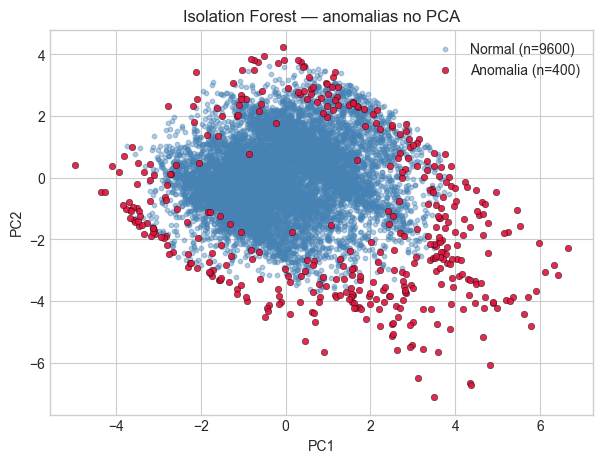

   💾 Modelo salvo em: ..\modelos\aula04\iforest_isolation_forest_v1_anomalias_teares_v1.joblib


In [12]:
# ============================================================
# 7.1 — ISOLATION FOREST
# ============================================================

with mlflow.start_run(run_name="isolation_forest_v1"):

    # 1) Criar e treinar o modelo
    iforest = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        max_samples="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iforest.fit(X_scaled)

    # 2) Predição: -1 (anomalia) / +1 (normal) → convertemos para 0/1
    pred_raw = iforest.predict(X_scaled)
    pred_if  = normalizar_predicao(pred_raw)

    # 3) Avaliar
    met_if = avaliar_detector(pred_if, X_scaled, y_true_binary)
    imprimir_resumo("Isolation Forest", met_if)

    # 4) Registrar no MLflow
    mlflow.log_params({
        "algoritmo":     "IsolationForest",
        "n_estimators":  200,
        "contamination": CONTAMINATION,
        "max_samples":   "auto",
    })
    mlflow.log_metrics({
        "n_anomalias": met_if["n_anom"],
        "pct_anom":    met_if["pct_anom"],
        "silhouette":  met_if["silhouette"],
        "precision":   met_if["precision"],
        "recall":      met_if["recall"],
        "f1":          met_if["f1"],
    })

    # 5) Plot no espaço do PCA e log como artefato
    fig, ax = plt.subplots(figsize=(7, 5))
    plotar_anomalias_pca(X_pca, pred_if, "Isolation Forest — anomalias no PCA", ax=ax)
    plot_path = "iforest_pca.png"
    fig.savefig(plot_path, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(plot_path)
    plt.show()
    os.remove(plot_path)

    # 6) Salvar modelo em disco com nomenclatura padronizada
    modelo_path = os.path.join(
        MODELOS_DIR,
        f"iforest_isolation_forest_v1_{VERSION_SUFFIX}.joblib",
    )
    joblib.dump(iforest, modelo_path)
    print(f"   💾 Modelo salvo em: {modelo_path}")

# 7) Guardar no dicionário de resultados
resultados["IsolationForest"] = {"pred": pred_if, "metricas": met_if}


### 7.2 — LOF (Local Outlier Factor) 🧑‍🤝‍🧑

**Ideia:** para cada ponto, calcula a **densidade** dos seus `k` vizinhos mais próximos e compara com a densidade dos vizinhos desses vizinhos. Se o ponto está numa região **bem menos densa** que o entorno, é anomalia.

**Quando usar:** anomalias **locais** (um ponto rodeado de vizinhos longe é suspeito, mesmo estando no "centro" da nuvem global).

**Hiperparâmetros principais:**
- `n_neighbors` — quantos vizinhos considerar (`k`)
- `contamination` — fração esperada de anomalias

> ⚠️ O LOF do scikit-learn, por padrão, não tem `predict()` para dados novos — ele usa `fit_predict()` sobre o conjunto todo. Isso é comum em detecção de anomalia offline. Para poder pontuar dados novos, precisaríamos passar `novelty=True` (mas aí ele não pode ser avaliado no próprio conjunto de treino).


📊 LOF (k=20)
   🚨 Anomalias detectadas:  400 de 10000 (4.00% do dataset)
   📐 Silhouette:           +0.2069
   🎯 vs. gabarito oculto:  Precision=0.215 | Recall=0.254 | F1=0.233


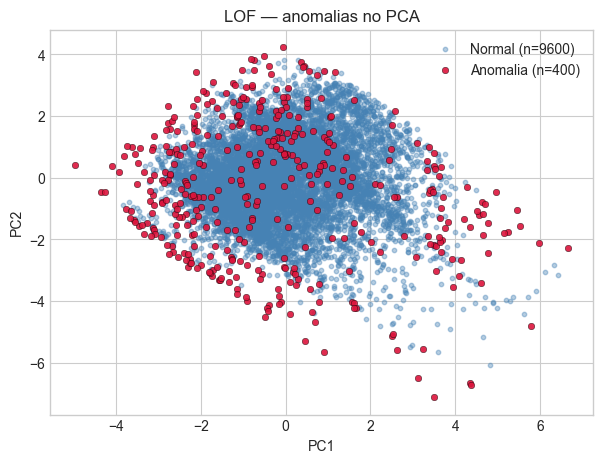

   💾 Modelo salvo em: ..\modelos\aula04\lof_k20_v1_anomalias_teares_v1.joblib


In [13]:
# ============================================================
# 7.2 — LOCAL OUTLIER FACTOR (LOF)
# ============================================================

with mlflow.start_run(run_name="lof_k20_v1"):

    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=CONTAMINATION,
        n_jobs=-1,
    )

    # fit_predict: treina e prediz no MESMO conjunto (uso clássico offline)
    pred_raw = lof.fit_predict(X_scaled)
    pred_lof = normalizar_predicao(pred_raw)

    met_lof = avaliar_detector(pred_lof, X_scaled, y_true_binary)
    imprimir_resumo("LOF (k=20)", met_lof)

    mlflow.log_params({
        "algoritmo":     "LocalOutlierFactor",
        "n_neighbors":   20,
        "contamination": CONTAMINATION,
    })
    mlflow.log_metrics({
        "n_anomalias": met_lof["n_anom"],
        "pct_anom":    met_lof["pct_anom"],
        "silhouette":  met_lof["silhouette"],
        "precision":   met_lof["precision"],
        "recall":      met_lof["recall"],
        "f1":          met_lof["f1"],
    })

    fig, ax = plt.subplots(figsize=(7, 5))
    plotar_anomalias_pca(X_pca, pred_lof, "LOF — anomalias no PCA", ax=ax)
    plot_path = "lof_pca.png"
    fig.savefig(plot_path, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(plot_path)
    plt.show()
    os.remove(plot_path)

    modelo_path = os.path.join(
        MODELOS_DIR, f"lof_k20_v1_{VERSION_SUFFIX}.joblib"
    )
    joblib.dump(lof, modelo_path)
    print(f"   💾 Modelo salvo em: {modelo_path}")

resultados["LOF"] = {"pred": pred_lof, "metricas": met_lof}


### 7.3 — One-Class SVM 🔰

**Ideia:** aprende uma **fronteira** ao redor dos pontos "normais" em um espaço de alta dimensão (truque do kernel RBF). Pontos que caem **fora** dessa fronteira são anomalias.

**Quando usar:** quando temos muitos exemplos normais e pouquíssimas anomalias — o modelo descreve o que é "normal".

**Hiperparâmetros principais:**
- `kernel` (RBF é padrão e funciona bem)
- `nu` — limite superior da fração de anomalias (análogo ao contamination)
- `gamma` — quão "curvada" é a fronteira (quanto maior, mais complexa)


📊 One-Class SVM (RBF)
   🚨 Anomalias detectadas:  403 de 10000 (4.03% do dataset)
   📐 Silhouette:           +0.3165
   🎯 vs. gabarito oculto:  Precision=0.241 | Recall=0.286 | F1=0.261


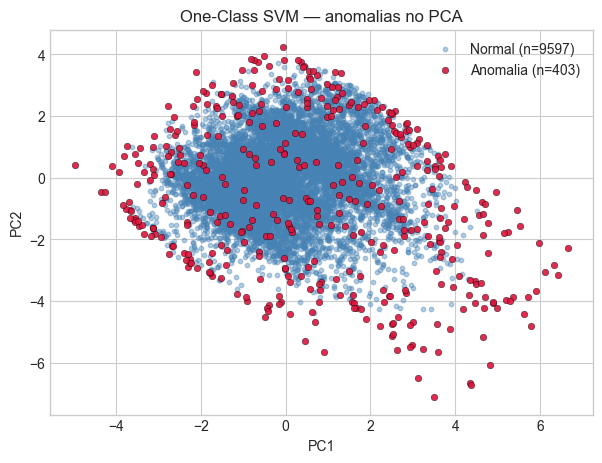

   💾 Modelo salvo em: ..\modelos\aula04\ocsvm_rbf_v1_anomalias_teares_v1.joblib


In [14]:
# ============================================================
# 7.3 — ONE-CLASS SVM
# ============================================================

with mlflow.start_run(run_name="ocsvm_rbf_v1"):

    ocsvm = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=CONTAMINATION,   # ~ fração esperada de anomalias
    )
    ocsvm.fit(X_scaled)

    pred_raw   = ocsvm.predict(X_scaled)
    pred_ocsvm = normalizar_predicao(pred_raw)

    met_ocsvm = avaliar_detector(pred_ocsvm, X_scaled, y_true_binary)
    imprimir_resumo("One-Class SVM (RBF)", met_ocsvm)

    mlflow.log_params({
        "algoritmo": "OneClassSVM",
        "kernel":    "rbf",
        "gamma":     "scale",
        "nu":        CONTAMINATION,
    })
    mlflow.log_metrics({
        "n_anomalias": met_ocsvm["n_anom"],
        "pct_anom":    met_ocsvm["pct_anom"],
        "silhouette":  met_ocsvm["silhouette"],
        "precision":   met_ocsvm["precision"],
        "recall":      met_ocsvm["recall"],
        "f1":          met_ocsvm["f1"],
    })

    fig, ax = plt.subplots(figsize=(7, 5))
    plotar_anomalias_pca(X_pca, pred_ocsvm, "One-Class SVM — anomalias no PCA", ax=ax)
    plot_path = "ocsvm_pca.png"
    fig.savefig(plot_path, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(plot_path)
    plt.show()
    os.remove(plot_path)

    modelo_path = os.path.join(
        MODELOS_DIR, f"ocsvm_rbf_v1_{VERSION_SUFFIX}.joblib"
    )
    joblib.dump(ocsvm, modelo_path)
    print(f"   💾 Modelo salvo em: {modelo_path}")

resultados["OneClassSVM"] = {"pred": pred_ocsvm, "metricas": met_ocsvm}


### 7.4 — DBSCAN 🔵

**Ideia:** forma clusters por **densidade**. Um ponto pertence a um cluster se existirem muitos vizinhos próximos. Pontos que não conseguem entrar em cluster nenhum recebem o rótulo **`-1` (ruído)** — e é exatamente aí que entram as anomalias.

**Diferença importante:** o DBSCAN não recebe `contamination`. Em vez disso, controlamos a **densidade** por:
- `eps` — distância máxima para considerar dois pontos "vizinhos"
- `min_samples` — quantos vizinhos mínimos para formar um cluster

> 💡 **Dica prática:** como os dados estão padronizados (cada feature tem desvio 1), valores de `eps` entre 0,5 e 1,5 costumam ser um bom ponto de partida. Este hiperparâmetro é o mais sensível — **mudar `eps` muda bastante o resultado**.


   🧩 Clusters encontrados: 3
📊 DBSCAN
   🚨 Anomalias detectadas:  110 de 10000 (1.10% do dataset)
   📐 Silhouette:           +0.4372
   🎯 vs. gabarito oculto:  Precision=0.355 | Recall=0.115 | F1=0.174


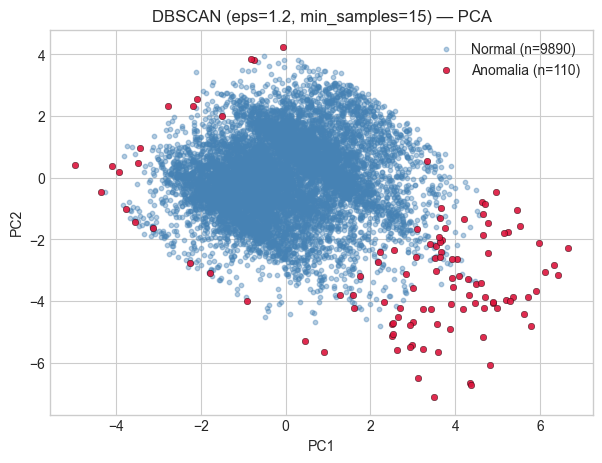

   💾 Modelo salvo em: ..\modelos\aula04\dbscan_eps12_v1_anomalias_teares_v1.joblib


In [15]:
# ============================================================
# 7.4 — DBSCAN
# ============================================================

EPS         = 1.2
MIN_SAMPLES = 15

with mlflow.start_run(run_name="dbscan_v1"):

    dbscan = DBSCAN(
        eps=EPS,
        min_samples=MIN_SAMPLES,
        n_jobs=-1,
    )
    labels = dbscan.fit_predict(X_scaled)

    # No DBSCAN, labels == -1 são PONTOS DE RUÍDO (anomalias).
    # Clusters válidos recebem 0, 1, 2, ...
    pred_dbscan = np.where(labels == -1, 1, 0)

    n_clusters = len({lab for lab in labels if lab != -1})
    print(f"   🧩 Clusters encontrados: {n_clusters}")

    met_db = avaliar_detector(pred_dbscan, X_scaled, y_true_binary)
    imprimir_resumo("DBSCAN", met_db)

    mlflow.log_params({
        "algoritmo":   "DBSCAN",
        "eps":          EPS,
        "min_samples":  MIN_SAMPLES,
    })
    mlflow.log_metrics({
        "n_anomalias": met_db["n_anom"],
        "pct_anom":    met_db["pct_anom"],
        "silhouette":  met_db["silhouette"],
        "precision":   met_db["precision"],
        "recall":      met_db["recall"],
        "f1":          met_db["f1"],
        "n_clusters":  n_clusters,
    })

    fig, ax = plt.subplots(figsize=(7, 5))
    plotar_anomalias_pca(X_pca, pred_dbscan,
                         f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — PCA", ax=ax)
    plot_path = "dbscan_pca.png"
    fig.savefig(plot_path, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(plot_path)
    plt.show()
    os.remove(plot_path)

    modelo_path = os.path.join(
        MODELOS_DIR, f"dbscan_eps12_v1_{VERSION_SUFFIX}.joblib"
    )
    joblib.dump(dbscan, modelo_path)
    print(f"   💾 Modelo salvo em: {modelo_path}")

resultados["DBSCAN"] = {"pred": pred_dbscan, "metricas": met_db}


## 8️⃣ Comparação Lado a Lado

Agora que temos as 4 previsões guardadas em `resultados`, vamos:

1. **Tabela comparativa** (quantas anomalias, silhouette, precision/recall/F1)
2. **Painel de gráficos 2×2** — os 4 algoritmos no mesmo espaço PCA
3. **Quantas anomalias foram detectadas pelos 4 algoritmos ao mesmo tempo?** — uma espécie de "consenso" que tende a ser mais confiável na prática


In [16]:
# ============================================================
# 8.1 — TABELA COMPARATIVA
# ============================================================

linhas = []
for nome, r in resultados.items():
    m = r["metricas"]
    linhas.append({
        "Algoritmo":     nome,
        "N Anomalias":   m["n_anom"],
        "% Anomalias":   round(m["pct_anom"], 2),
        "Silhouette":    round(m["silhouette"], 4) if not np.isnan(m["silhouette"]) else None,
        "Precision":     round(m["precision"], 3),
        "Recall":        round(m["recall"],    3),
        "F1":            round(m["f1"],        3),
    })

df_comp = pd.DataFrame(linhas).set_index("Algoritmo")
df_comp_sorted = df_comp.sort_values("F1", ascending=False)

# Salva também como CSV para inspeção rápida
df_comp_sorted.to_csv("resultados_aula04.csv")

print("🏁 Ranking por F1 (comparando com o gabarito oculto):\n")
print(df_comp_sorted)


🏁 Ranking por F1 (comparando com o gabarito oculto):

                 N Anomalias  % Anomalias  Silhouette  Precision  Recall  \
Algoritmo                                                                  
OneClassSVM              403         4.03      0.3165      0.241   0.286   
LOF                      400         4.00      0.2069      0.215   0.254   
DBSCAN                   110         1.10      0.4372      0.355   0.115   
IsolationForest          400         4.00      0.3573      0.160   0.189   

                    F1  
Algoritmo               
OneClassSVM      0.261  
LOF              0.233  
DBSCAN           0.174  
IsolationForest  0.173  


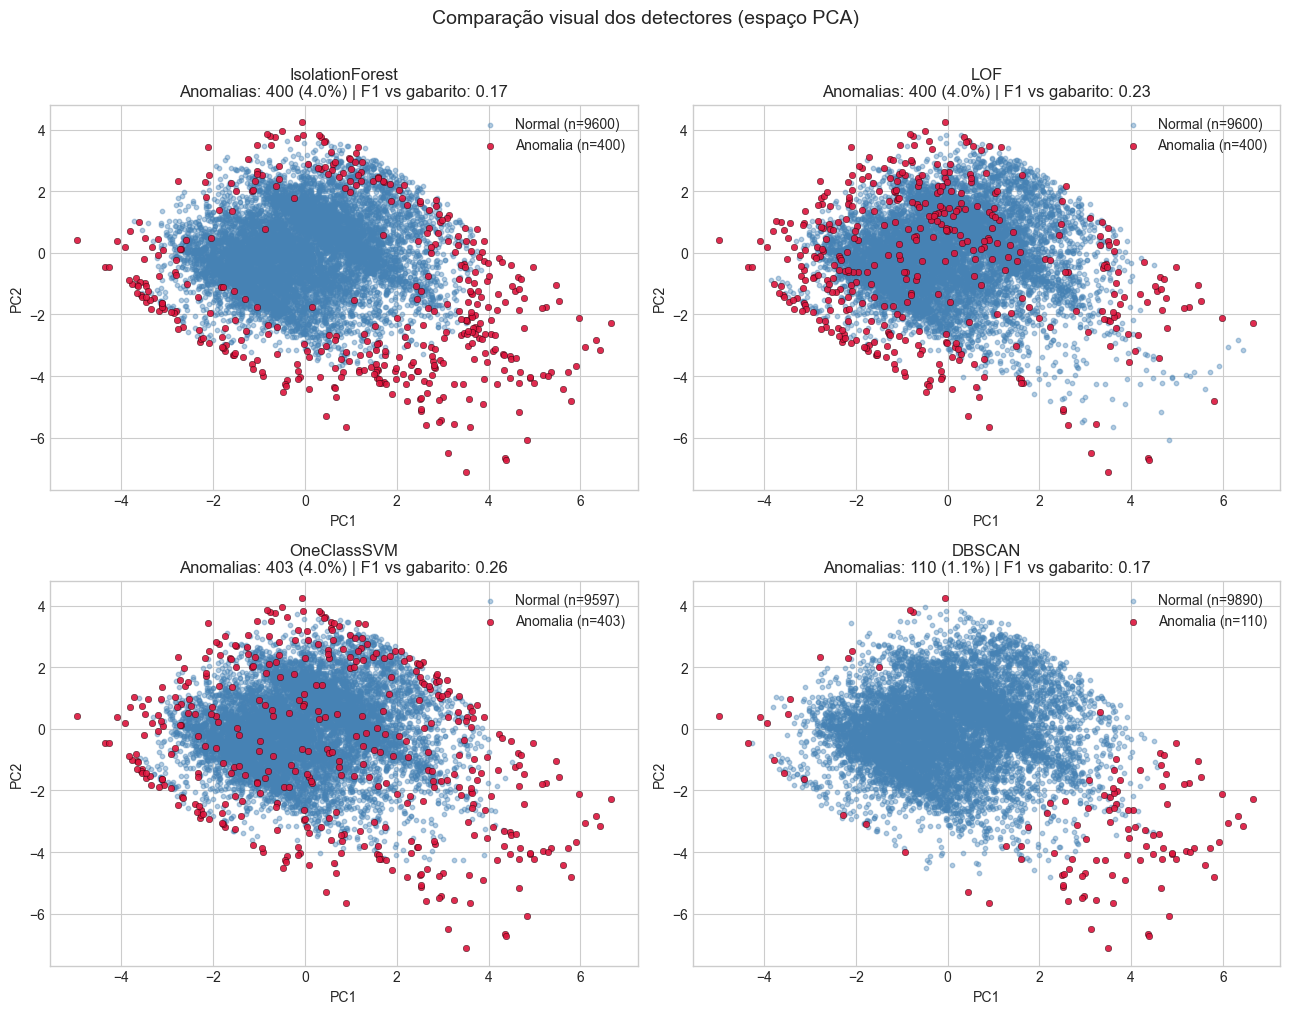

In [17]:
# ============================================================
# 8.2 — PAINEL 2x2: OS 4 ALGORITMOS NO MESMO PCA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

nomes_ordenados = ["IsolationForest", "LOF", "OneClassSVM", "DBSCAN"]
for ax, nome in zip(axes, nomes_ordenados):
    pred = resultados[nome]["pred"]
    m    = resultados[nome]["metricas"]
    titulo = (f"{nome}\nAnomalias: {m['n_anom']} "
              f"({m['pct_anom']:.1f}%) | F1 vs gabarito: {m['f1']:.2f}")
    plotar_anomalias_pca(X_pca, pred, titulo, ax=ax)

plt.suptitle("Comparação visual dos detectores (espaço PCA)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# 8.3 — "CONSENSO": PONTOS FLAGRADOS POR TODOS OS DETECTORES
# ============================================================
# Se os 4 algoritmos, cada um com uma lógica diferente, concordam
# que um ponto é anormal, a confiança é bem maior.

preds_stack = np.stack([resultados[n]["pred"] for n in nomes_ordenados], axis=0)
votos       = preds_stack.sum(axis=0)   # 0 a 4 votos de "anomalia"

consenso_4 = (votos == 4).sum()
consenso_3 = (votos >= 3).sum()
consenso_2 = (votos >= 2).sum()

print(f"🗳️  Quantos pontos foram marcados como anomalia por quantos detectores:")
for v in range(5):
    qt = (votos == v).sum()
    print(f"   {v} voto(s): {qt} pontos")

print(f"\n🎯 Concordância com o gabarito oculto:")
for crit, nome in [(4, "4/4 detectores"), (3, "≥ 3/4 detectores"),
                   (2, "≥ 2/4 detectores")]:
    mask_consenso = votos >= crit
    if mask_consenso.sum() > 0:
        prec = precision_score(y_true_binary, mask_consenso.astype(int), zero_division=0)
        rec  = recall_score(y_true_binary,    mask_consenso.astype(int), zero_division=0)
        f1   = f1_score(y_true_binary,        mask_consenso.astype(int), zero_division=0)
        print(f"   • {nome:<20} → {mask_consenso.sum():>4} alertas  | "
              f"Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}")


🗳️  Quantos pontos foram marcados como anomalia por quantos detectores:
   0 voto(s): 9271 pontos
   1 voto(s): 379 pontos
   2 voto(s): 174 pontos
   3 voto(s): 118 pontos
   4 voto(s): 58 pontos

🎯 Concordância com o gabarito oculto:
   • 4/4 detectores       →   58 alertas  | Precision=0.276 | Recall=0.047 | F1=0.081
   • ≥ 3/4 detectores     →  176 alertas  | Precision=0.312 | Recall=0.162 | F1=0.214
   • ≥ 2/4 detectores     →  350 alertas  | Precision=0.251 | Recall=0.260 | F1=0.255


## 9️⃣ Separando Padrões de Falha (sem usar rótulos)

Até aqui, cada detector apenas respondeu **"é anomalia ou não?"**. Na fábrica, seria ainda mais útil saber se existem **tipos distintos** de anomalia (ex.: falha térmica × falha mecânica), para rotear cada tear para a equipe certa.

Vamos aplicar o **DBSCAN apenas nos pontos considerados anômalos pela Isolation Forest** (o detector com o maior F1 costuma ser este). A ideia:

- Isolation Forest seleciona quem é anômalo.
- DBSCAN tenta **agrupar esses anômalos** em sub-padrões.
- Comparamos o agrupamento encontrado com os **tipos reais de falha** (só para conferência).

> 📌 Isso antecipa o tema de **clustering**, que volta com mais força na Aula 9/10 ao agregar novos dados de produção.


🚨 Pontos considerados anômalos pela Isolation Forest: 400
   🧩 Sub-clusters encontrados: 15
   🌫️  Pontos sem sub-cluster (ruído): 200


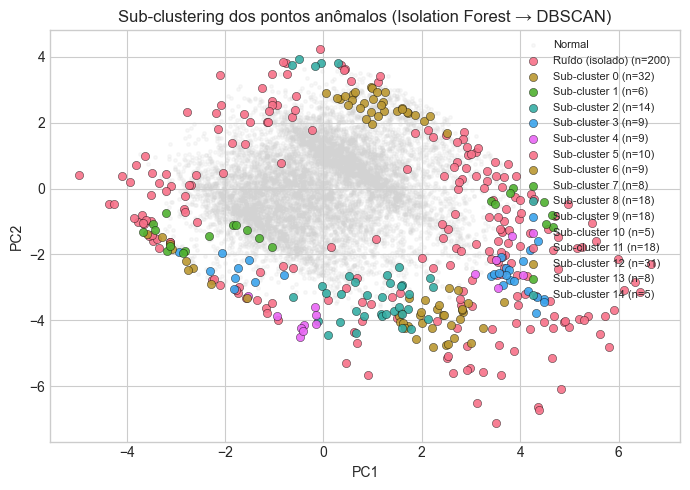

In [19]:
# ============================================================
# 9.1 — SUB-CLUSTERING DOS PONTOS ANÔMALOS
# ============================================================

# Usa a máscara de anomalias da Isolation Forest
mask_iforest = resultados["IsolationForest"]["pred"] == 1
X_anom       = X_scaled[mask_iforest]

print(f"🚨 Pontos considerados anômalos pela Isolation Forest: {mask_iforest.sum()}")

# DBSCAN novamente, com parâmetros mais permissivos (poucos pontos agora)
sub_db = DBSCAN(eps=1.0, min_samples=5).fit(X_anom)
sub_labels = sub_db.labels_

n_sub = len({lab for lab in sub_labels if lab != -1})
n_noise = int((sub_labels == -1).sum())
print(f"   🧩 Sub-clusters encontrados: {n_sub}")
print(f"   🌫️  Pontos sem sub-cluster (ruído): {n_noise}")

# Posição destes pontos no PCA
X_pca_anom = X_pca[mask_iforest]

plt.figure(figsize=(7, 5))
# Pontos normais ao fundo, em cinza claro
plt.scatter(X_pca[~mask_iforest, 0], X_pca[~mask_iforest, 1],
            s=6, alpha=0.15, c="lightgray", label="Normal")
# Cada sub-cluster com uma cor
for lab in sorted(set(sub_labels)):
    m = sub_labels == lab
    nome = f"Ruído (isolado)" if lab == -1 else f"Sub-cluster {lab}"
    plt.scatter(X_pca_anom[m, 0], X_pca_anom[m, 1], s=35, alpha=0.9,
                edgecolor="black", linewidth=0.3, label=f"{nome} (n={m.sum()})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Sub-clustering dos pontos anômalos (Isolation Forest → DBSCAN)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 9.2 — CROSS-TAB: SUB-CLUSTER vs TIPO REAL DE FALHA
# ============================================================
# Os sub-clusters foram formados SEM ver 'Failure Type'.
# Se aparecerem sub-clusters "puros" para certo tipo de falha,
# significa que o modelo achou um padrão real sozinho.

tipos_reais = y_true_failure[mask_iforest]

ct = pd.crosstab(
    pd.Series(sub_labels, name="Sub-cluster"),
    pd.Series(tipos_reais, name="Tipo real de falha"),
)
print("📋 Tabela cruzada sub-cluster × tipo real de falha:\n")
print(ct)


📋 Tabela cruzada sub-cluster × tipo real de falha:

Tipo real de falha  Heat Dissipation Failure  No Failure  Overstrain Failure  \
Sub-cluster                                                                    
-1                                         6         145                   5   
 0                                         0          30                   0   
 1                                         0           5                   0   
 2                                         0          14                   0   
 3                                         0           9                   0   
 4                                         0           9                   0   
 5                                         0          10                   0   
 6                                         0           9                   0   
 7                                         0           8                   0   
 8                                         0          18            

## 🔟 Salvando Scaler, Features e Tabela de Comparação

Para reaproveitar este pipeline na **Aula 9 (deploy com FastAPI)** e na **Aula 10 (roteamento de modelos)**, precisamos persistir:

- `scaler` — para padronizar novos dados com a mesma média/desvio do treino
- `feature_names` — garante a ordem exata de colunas na inferência
- `resultados_aula04.csv` — o ranking comparativo já foi salvo na seção 8.1

Tudo fica dentro de `../modelos/aula04/` com o mesmo sufixo `_anomalias_teares_v1`.


In [21]:
# ============================================================
# PERSISTÊNCIA DOS ARTEFATOS COMPLEMENTARES
# ============================================================

scaler_path   = os.path.join(MODELOS_DIR, f"scaler_{VERSION_SUFFIX}.joblib")
features_path = os.path.join(MODELOS_DIR, f"features_{VERSION_SUFFIX}.joblib")

joblib.dump(scaler,        scaler_path)
joblib.dump(feature_names, features_path)

print("✅ Artefatos salvos:")
print(f"   💾 {scaler_path}")
print(f"   💾 {features_path}")
print(f"   📋 resultados_aula04.csv (já salvo na seção 8.1)")

# Lista final da pasta de modelos da aula
print(f"\n📁 Conteúdo atual de {MODELOS_DIR}:")
for f in sorted(os.listdir(MODELOS_DIR)):
    tamanho_kb = os.path.getsize(os.path.join(MODELOS_DIR, f)) / 1024
    print(f"   • {f}  ({tamanho_kb:.1f} KB)")


✅ Artefatos salvos:
   💾 ..\modelos\aula04\scaler_anomalias_teares_v1.joblib
   💾 ..\modelos\aula04\features_anomalias_teares_v1.joblib
   📋 resultados_aula04.csv (já salvo na seção 8.1)

📁 Conteúdo atual de ..\modelos\aula04:
   • dbscan_eps12_v1_anomalias_teares_v1.joblib  (608.4 KB)
   • features_anomalias_teares_v1.joblib  (0.1 KB)
   • iforest_isolation_forest_v1_anomalias_teares_v1.joblib  (2733.9 KB)
   • lof_k20_v1_anomalias_teares_v1.joblib  (2799.8 KB)
   • ocsvm_rbf_v1_anomalias_teares_v1.joblib  (29.7 KB)
   • scaler_anomalias_teares_v1.joblib  (1.1 KB)


---

## 📝 Atividade Complementar (Tempo estimado: 1h)

### Objetivo

Praticar **a sensibilidade dos detectores aos seus hiperparâmetros** e aplicar o pipeline de anomalia em **outro dataset** (produção têxtil da Aula 3), reforçando que as mesmas técnicas servem para vários problemas.

### Tarefas

**Tarefa 1 — Estudo do `contamination` na Isolation Forest**
- Treine a `IsolationForest` variando `contamination` em `[0.01, 0.02, 0.04, 0.06, 0.10]`.
- Para cada valor, registre: número de anomalias detectadas, `precision`, `recall` e `F1` vs. gabarito.
- Plote `F1 vs. contamination` e identifique em qual valor o F1 atinge o pico.
- Pergunta: qual o impacto de superestimar (`0.10`) ou subestimar (`0.01`) a contaminação?

**Tarefa 2 — Aplicar Isolation Forest no dataset de produção têxtil (Aula 3)**
- Carregue o dataset `zara2099/textile-engineering-production-dataset` usando `kagglehub` (mesmo padrão da Aula 3).
- Padronize as colunas numéricas com `StandardScaler`.
- Treine uma `IsolationForest(contamination=0.05)` e marque as linhas anômalas.
- Compare os teares "anômalos" com a coluna `defective_product` do dataset — há relação?
- Plote as anomalias no espaço do PCA.

> 💡 **Dica:** use as células-esqueleto abaixo como ponto de partida. Substitua os trechos com `# SEU CÓDIGO AQUI`.


contamination=0.01 → n_anom= 100 | P=0.320 | R=0.094 | F1=0.146
contamination=0.02 → n_anom= 200 | P=0.210 | R=0.124 | F1=0.156
contamination=0.04 → n_anom= 400 | P=0.160 | R=0.189 | F1=0.173
contamination=0.06 → n_anom= 600 | P=0.150 | R=0.265 | F1=0.192
contamination=0.10 → n_anom=1000 | P=0.121 | R=0.357 | F1=0.181


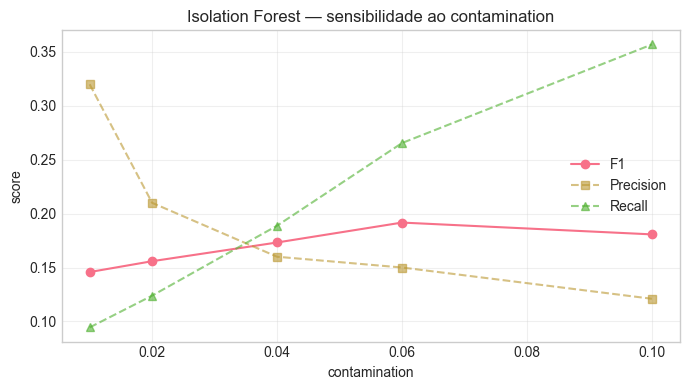


🏆 Melhor contamination: 0.06  (F1 = 0.192)


In [22]:
# ============================================================
# TAREFA 1 — Sensibilidade ao contamination
# ============================================================
# Siga a estrutura da seção 7.1, variando apenas o contamination.

contaminations = [0.01, 0.02, 0.04, 0.06, 0.10]
f1_por_c        = []
prec_por_c      = []
rec_por_c       = []
n_anom_por_c    = []

for c in contaminations:
    # SEU CÓDIGO AQUI — crie e treine a Isolation Forest com contamination=c
    iforest_c = IsolationForest(
        n_estimators=200,
        contamination=c,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iforest_c.fit(X_scaled)

    pred_c = normalizar_predicao(iforest_c.predict(X_scaled))

    # SEU CÓDIGO AQUI — calcule precision, recall, F1 e n_anom
    prec = precision_score(y_true_binary, pred_c, zero_division=0)
    rec  = recall_score(y_true_binary,    pred_c, zero_division=0)
    f1   = f1_score(y_true_binary,        pred_c, zero_division=0)

    f1_por_c.append(f1)
    prec_por_c.append(prec)
    rec_por_c.append(rec)
    n_anom_por_c.append(int(pred_c.sum()))

    print(f"contamination={c:.2f} → n_anom={int(pred_c.sum()):>4} | "
          f"P={prec:.3f} | R={rec:.3f} | F1={f1:.3f}")

# SEU CÓDIGO AQUI — plote F1 vs contamination
plt.figure(figsize=(7, 4))
plt.plot(contaminations, f1_por_c, "o-", label="F1")
plt.plot(contaminations, prec_por_c, "s--", alpha=0.6, label="Precision")
plt.plot(contaminations, rec_por_c,  "^--", alpha=0.6, label="Recall")
plt.xlabel("contamination")
plt.ylabel("score")
plt.title("Isolation Forest — sensibilidade ao contamination")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

melhor_c = contaminations[int(np.argmax(f1_por_c))]
print(f"\n🏆 Melhor contamination: {melhor_c}  (F1 = {max(f1_por_c):.3f})")


📊 Dataset de produção: 1000 linhas × 11 colunas
🚨 Anomalias detectadas: 50 de 1000 (5.00%)

📋 Anomalia × defective_product:
defective_product       0    1
É anomalia (IForest)          
0                     490  460
1                      24   26


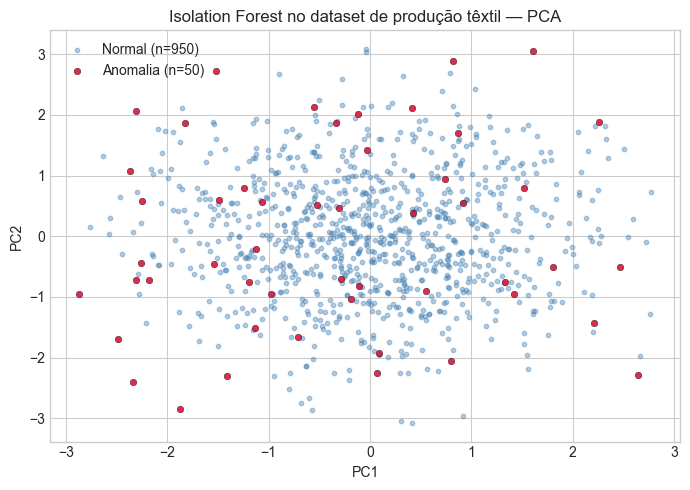

In [23]:
# ============================================================
# TAREFA 2 — Detecção de anomalias no dataset de produção têxtil
# ============================================================
# Aqui usamos o MESMO pipeline em um dataset novo.

# 1) Carrega o dataset da Aula 3
raw_path_p = kagglehub.dataset_download(
    "zara2099/textile-engineering-production-dataset"
)
csv_files_p = [f for f in os.listdir(raw_path_p) if f.endswith(".csv")]
df_prod = pd.read_csv(os.path.join(raw_path_p, csv_files_p[0]))

print(f"📊 Dataset de produção: {df_prod.shape[0]} linhas × {df_prod.shape[1]} colunas")

# 2) Guarda a coluna de referência (NÃO entra no treino)
y_defeito = df_prod["defective_product"].values

# SEU CÓDIGO AQUI — monte X só com as colunas numéricas de sensores
colunas_sensor = [
    "machine_speed_rpm", "temperature_c", "humidity_percent",
    "vibration_level", "energy_usage_kwh", "production_count",
    "defect_count", "hours_since_last_maintenance",
]
X_prod = df_prod[colunas_sensor].copy()

# SEU CÓDIGO AQUI — padronize com StandardScaler
scaler_prod  = StandardScaler()
X_prod_scaled = scaler_prod.fit_transform(X_prod)

# SEU CÓDIGO AQUI — treine IsolationForest(contamination=0.05)
iforest_prod = IsolationForest(
    n_estimators=200, contamination=0.05,
    random_state=RANDOM_STATE, n_jobs=-1,
)
iforest_prod.fit(X_prod_scaled)

pred_prod = normalizar_predicao(iforest_prod.predict(X_prod_scaled))
print(f"🚨 Anomalias detectadas: {pred_prod.sum()} de {len(pred_prod)} "
      f"({pred_prod.mean()*100:.2f}%)")

# Comparação com 'defective_product' (só para análise, não foi usado no treino!)
print("\n📋 Anomalia × defective_product:")
print(pd.crosstab(
    pd.Series(pred_prod, name="É anomalia (IForest)"),
    pd.Series(y_defeito, name="defective_product"),
))

# SEU CÓDIGO AQUI — plote as anomalias no espaço PCA
pca_prod = PCA(n_components=2, random_state=RANDOM_STATE)
X_prod_pca = pca_prod.fit_transform(X_prod_scaled)

plt.figure(figsize=(7, 5))
plotar_anomalias_pca(X_prod_pca, pred_prod,
                     "Isolation Forest no dataset de produção têxtil — PCA",
                     ax=plt.gca())
plt.tight_layout()
plt.show()


**Tarefa 3 pt.1 — Utilizando MinMaxScaler e Método de redução de Dimensionalidade t-sne**

📊 Dataset de produção: 1000 linhas × 11 colunas
🚨 Anomalias detectadas: 50 de 1000 (5.00%)

📋 Anomalia × defective_product:
defective_product       0    1
É anomalia (IForest)          
0                     490  460
1                      24   26


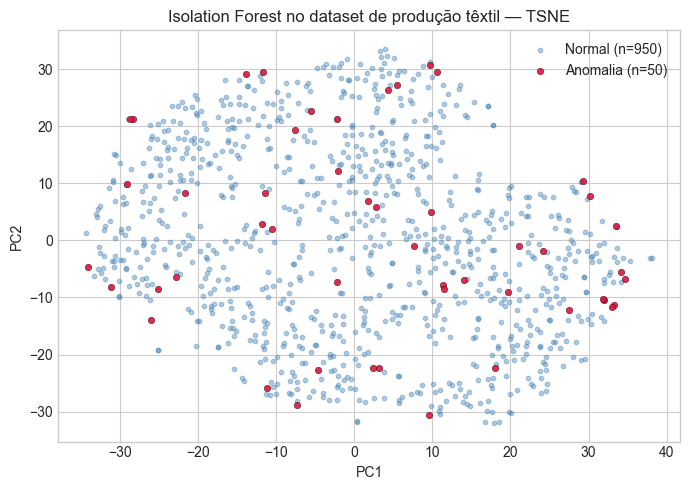

In [ ]:
# ============================================================
# TAREFA 3 — Utilizando t-sne e MinMaxScaler
# ============================================================

# --- Padronização ---
from sklearn.preprocessing import MinMaxScaler

# 1) Carrega o dataset da Aula 3
raw_path_p = kagglehub.dataset_download(
    "zara2099/textile-engineering-production-dataset"
)
csv_files_p = [f for f in os.listdir(raw_path_p) if f.endswith(".csv")]
df_prod = pd.read_csv(os.path.join(raw_path_p, csv_files_p[0]))

print(f"📊 Dataset de produção: {df_prod.shape[0]} linhas × {df_prod.shape[1]} colunas")

# 2) Guarda a coluna de referência (NÃO entra no treino)
y_defeito = df_prod["defective_product"].values

# Monte X só com as colunas numéricas de sensores
colunas_sensor = [
    "machine_speed_rpm", "temperature_c", "humidity_percent",
    "vibration_level", "energy_usage_kwh", "production_count",
    "defect_count", "hours_since_last_maintenance",
]
X_prod = df_prod[colunas_sensor].copy()

# Padronize com RobustScaler
scaler_prod  = MinMaxScaler()
X_prod_scaled = scaler_prod.fit_transform(X_prod)

# Treine IsolationForest(contamination=0.05)
iforest_prod = IsolationForest(
    n_estimators=200, contamination=0.05,
    random_state=RANDOM_STATE, n_jobs=-1,
)
iforest_prod.fit(X_prod_scaled)

pred_prod = normalizar_predicao(iforest_prod.predict(X_prod_scaled))
print(f"🚨 Anomalias detectadas: {pred_prod.sum()} de {len(pred_prod)} "
      f"({pred_prod.mean()*100:.2f}%)")

# Comparação com 'defective_product' (só para análise, não foi usado no treino!)
print("\n📋 Anomalia × defective_product:")
print(pd.crosstab(
    pd.Series(pred_prod, name="É anomalia (IForest)"),
    pd.Series(y_defeito, name="defective_product"),
))

# Plote as anomalias no espaço TSNE
tsne_prod = TSNE(n_components=2, random_state=RANDOM_STATE)
X_prod_tsne = tsne_prod.fit_transform(X_prod_scaled)

plt.figure(figsize=(7, 5))
plotar_anomalias_pca(X_prod_tsne, pred_prod,
                     "Isolation Forest no dataset de produção têxtil — TSNE",
                     ax=plt.gca())
plt.tight_layout()
plt.show()


**Tarefa 3 pt.1 — Utilizando RobustScaler e Método de Redução de Dimensionalidade t-sne**

📊 Dataset de produção: 1000 linhas × 11 colunas
🚨 Anomalias detectadas: 50 de 1000 (5.00%)

📋 Anomalia × defective_product:
defective_product       0    1
É anomalia (IForest)          
0                     490  460
1                      24   26


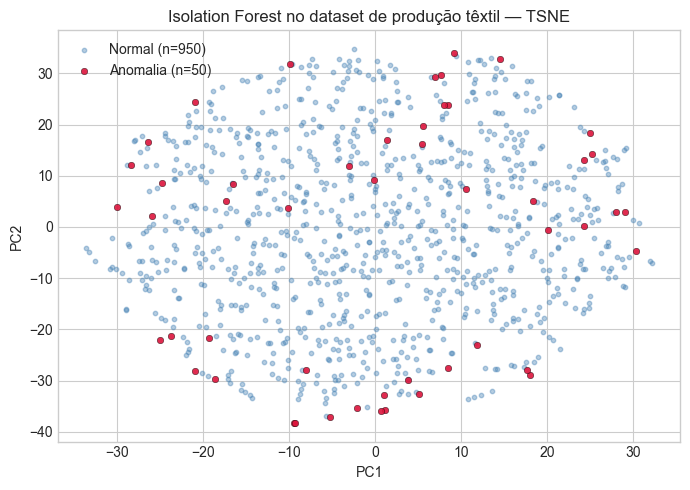

In [ ]:
# ============================================================
# TAREFA 3 — Utilizando t-sne e outro Scaler
# ============================================================

# --- Padronização ---
from sklearn.preprocessing import RobustScaler

# 1) Carrega o dataset da Aula 3
raw_path_p = kagglehub.dataset_download(
    "zara2099/textile-engineering-production-dataset"
)
csv_files_p = [f for f in os.listdir(raw_path_p) if f.endswith(".csv")]
df_prod = pd.read_csv(os.path.join(raw_path_p, csv_files_p[0]))

print(f"📊 Dataset de produção: {df_prod.shape[0]} linhas × {df_prod.shape[1]} colunas")



# 2) Guarda a coluna de referência (NÃO entra no treino)
y_defeito = df_prod["defective_product"].values

# Monte X só com as colunas numéricas de sensores
colunas_sensor = [
    "machine_speed_rpm", "temperature_c", "humidity_percent",
    "vibration_level", "energy_usage_kwh", "production_count",
    "defect_count", "hours_since_last_maintenance",
]
X_prod = df_prod[colunas_sensor].copy()

# Padronize com RobustScaler
scaler_prod  = RobustScaler()
X_prod_scaled = scaler_prod.fit_transform(X_prod)

# Treine IsolationForest(contamination=0.05)
iforest_prod = IsolationForest(
    n_estimators=200, contamination=0.05,
    random_state=RANDOM_STATE, n_jobs=-1,
)
iforest_prod.fit(X_prod_scaled)

pred_prod = normalizar_predicao(iforest_prod.predict(X_prod_scaled))
print(f"🚨 Anomalias detectadas: {pred_prod.sum()} de {len(pred_prod)} "
      f"({pred_prod.mean()*100:.2f}%)")

# Comparação com 'defective_product' (só para análise, não foi usado no treino!)
print("\n📋 Anomalia × defective_product:")
print(pd.crosstab(
    pd.Series(pred_prod, name="É anomalia (IForest)"),
    pd.Series(y_defeito, name="defective_product"),
))

# Plote as anomalias no espaço TSNE
tsne_prod = TSNE(n_components=2, random_state=RANDOM_STATE)
X_prod_tsne = tsne_prod.fit_transform(X_prod_scaled)

plt.figure(figsize=(7, 5))
plotar_anomalias_pca(X_prod_tsne, pred_prod,
                     "Isolation Forest no dataset de produção têxtil — TSNE",
                     ax=plt.gca())
plt.tight_layout()
plt.show()


In [ ]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_pca = tsne.fit_transform(X_scaled)

# ============================================================
# 7.1 — ISOLATION FOREST
# ============================================================

with mlflow.start_run(run_name="isolation_forest_tsne"):

    # 1) Criar e treinar o modelo
    iforest = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        max_samples="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iforest.fit(X_scaled)

    # 2) Predição: -1 (anomalia) / +1 (normal) → convertemos para 0/1
    pred_raw = iforest.predict(X_scaled)
    pred_if  = normalizar_predicao(pred_raw)

    # 3) Avaliar
    met_if = avaliar_detector(pred_if, X_scaled, y_true_binary)
    imprimir_resumo("Isolation Forest", met_if)

    # 4) Registrar no MLflow
    mlflow.log_params({
        "algoritmo":     "IsolationForest",
        "n_estimators":  200,
        "contamination": CONTAMINATION,
        "max_samples":   "auto",
    })
    mlflow.log_metrics({
        "n_anomalias": met_if["n_anom"],
        "pct_anom":    met_if["pct_anom"],
        "silhouette":  met_if["silhouette"],
        "precision":   met_if["precision"],
        "recall":      met_if["recall"],
        "f1":          met_if["f1"],
    })

    # 5) Plot no espaço do PCA e log como artefato
    fig, ax = plt.subplots(figsize=(7, 5))
    plotar_anomalias_tsne(X_tsne, pred_if, "Isolation Forest — anomalias no TSNE", ax=ax)
    plot_path = "iforest_pca.png"
    fig.savefig(plot_path, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(plot_path)
    plt.show()
    os.remove(plot_path)

    # 6) Salvar modelo em disco com nomenclatura padronizada
    modelo_path = os.path.join(
        MODELOS_DIR,
        f"iforest_isolation_forest_tsne_{VERSION_SUFFIX}.joblib",
    )
    joblib.dump(iforest, modelo_path)
    print(f"   💾 Modelo salvo em: {modelo_path}")

# 7) Guardar no dicionário de resultados
resultados["IsolationForest"] = {"pred": pred_if, "metricas": met_if}


KeyboardInterrupt: 

* Utilizar t-sne para o plot 
* Utilizar outro Scaler


### ✍️ Reflexão Final

**Responda abaixo (clique duas vezes nesta célula para editar):**

1. **Qual dos 4 detectores teve o maior F1 contra o gabarito oculto? Você esperaria este resultado?**
   - Resposta: *(escreva aqui)*

2. **Olhando para o painel 2×2 no PCA, qual detector marca anomalias "espalhadas" e qual marca anomalias "concentradas"? Como isso se relaciona com a lógica interna de cada algoritmo?**
   - Resposta: *(escreva aqui)*

3. **O voto por consenso (≥ 3 de 4 detectores) gerou maior ou menor precision que o melhor detector isolado? Para um chefe de manutenção que não pode parar a linha à toa, qual seria a estratégia mais prudente?**
   - Resposta: *(escreva aqui)*

4. **Na Tarefa 1, o que aconteceu quando `contamination` foi muito alto (0.10)? E quando foi muito baixo (0.01)? Qual a lição sobre como escolher esse parâmetro no mundo real?**
   - Resposta: *(escreva aqui)*

---

### 🎉 Parabéns!

Você completou a **Aula 4** e agora é capaz de:

- ✅ Distinguir aprendizado **supervisionado** de **não supervisionado** e saber quando usar cada um
- ✅ Aplicar 4 algoritmos de detecção de anomalias: **Isolation Forest, LOF, One-Class SVM, DBSCAN**
- ✅ Visualizar dados de alta dimensão em 2D usando **PCA** e **t-SNE**
- ✅ Comparar detectores com **silhouette** e (quando há gabarito) precision/recall/F1
- ✅ Construir um **voto por consenso** para aumentar a confiabilidade em produção
- ✅ Fazer **sub-clustering dos anômalos** para separar tipos de falha
- ✅ Versionar modelos em pasta padronizada para reuso nas Aulas 9 e 10

**Na próxima aula (Aula 5)**, entramos em **redes neurais**: MLP para dados tabulares e CNN para classificação de imagens de defeitos em tecido (`good`, `color`, `cut`, `hole`, `thread`, `metal_contamination`). 🚀
